# 预测模型

[数据来源：Kaggle](https://www.kaggle.com/sulianova/cardiovascular-disease-dataset/code)

**数据描述：**

共有 3 种类型的输入特征：

* 客观特征 (Objective)：事实信息；
* 检查特征 (Examination)：体检结果；
* 主观特征 (Subjective)：病人提供的信息。
  
**原始数据特征详情：**

* 年龄 | 客观特征 | age | 整数 (天)
* 身高 | 客观特征 | height | 整数 (厘米) |
* 体重 | 客观特征 | weight | 浮点数 (千克) |
* 性别 | 客观特征 | gender | 分类代码 | 1 - 女性, 2 - 男性 |
* 收缩压 | 检查特征 | ap_hi | 整数 |
* 舒张压 | 检查特征 | ap_lo | 整数 |
* 胆固醇 | 检查特征 | cholesterol | 1: 正常, 2: 高于正常, 3: 远高于正常 |
* 血糖 | 检查特征 | gluc | 1: 正常, 2: 高于正常, 3: 远高于正常 |
* 吸烟 | 主观特征 | smoke | 二值 | 0: 否, 1: 是 |
* 饮酒 | 主观特征 | alco | 二值 | 0: 否, 1: 是 |
* 体育锻炼 | 主观特征 | active | 二值 | 0: 否, 1: 是 |
* 是否存在心血管疾病 | 目标变量 | cardio | 二值 | 0: 否, 1: 是 |
  
数据集中的所有数值均在体检时收集。

**基于原始数据创建的特征：**
* BMI - 身体质量指数 | 0: 体重过轻, 1: 正常, 2: 超重, 3: 1级肥胖, 4: 2级肥胖, 5: 3级肥胖（病态肥胖）
* cat_blood_pressure | 0: 正常, 1: 血压升高, 2: 1级高血压, 3: 2级高血压, 4: 3级高血压。
* cat_weight | 0: 体重过轻, 1: 正常, 2: 偏高, 3: 超重, 4: 肥胖, 5: 重度肥胖（病态肥胖）。

## 1.导入必要的库

In [23]:
# 基础库导入
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt

# 机器学习模型与工具
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, recall_score
from sklearn.metrics import precision_score, f1_score, cohen_kappa_score, balanced_accuracy_score

# 忽略警告信息，保持输出界面整洁
warnings.filterwarnings('ignore')

## 2.全局设置与辅助函数

In [ ]:
# 设置随机种子，保证每次运行的结果一致
SEED = 43
random.seed(SEED)
np.random.seed(SEED)

# 魔法命令，确保图表在Notebook中直接显示
%matplotlib inline

# Matplotlib 全局参数设置
plt.style.use('bmh')
plt.rcParams['figure.figsize'] = [16, 8]
plt.rcParams['font.size'] = 18

# Pandas 全局显示设置 (显示所有列和行，不换行)
pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.set_option('display.expand_frame_repr', False)

sns.set()

# --- 辅助函数 1：BMI 分类函数 ---
# 0: 体重过轻, 1: 正常, 2: 超重, 3: 1级肥胖, 4: 2级肥胖, 5: 3级肥胖
def cat_bmi(bmi):
    if bmi < 18.5:
        return int(0) # 0: 体重过轻
    elif 18.5 <= bmi < 25:
        return int(1) # 1: 正常
    elif 25 <= bmi < 30:
        return int(2) # 2: 超重
    elif 30 <= bmi < 35:
        return int(3) # 3: 1级肥胖
    elif 35 <= bmi < 40:
        return int(4) # 4: 2级肥胖
    else: # bmi >= 40
        return int(5) # 5: 3级肥胖
# --- 辅助函数 2：柱状图数值自动标注函数 ---
def annot_plot(plot):
    for p in plot.patches:
        plot.annotate(format(int(p.get_height())),
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha = 'center', va = 'center',
                      xytext = (0, 9),
                      textcoords = 'offset points',
                      fontsize = 14)
    return None

## 3.加载数据集

In [25]:
try:
    df1 = pd.read_csv('data\\cardio_train.csv', sep=';', index_col='id')
    print("数据加载成功！")
except FileNotFoundError:
    print("错误：未找到数据文件，请检查文件路径是否正确！")

# 预览前5行数据

df1.head()

数据加载成功！


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
id,,,,,,,,,,,,
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 4.数据描述

In [26]:
# 查看各类数据的数据类型

df1.dtypes

age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [27]:
# 检查是否存在缺失值

df1.isnull().sum().sum()

0

In [28]:
# 数据集概览

df1.describe().T

,count,mean,std,min,25%,50%,75%,max
age,70000.0,19468.865814,2467.251667,10798.0,17664.0,19703.0,21327.0,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.0,1.0,2.0,2.0
height,70000.0,164.359229,8.210126,55.0,159.0,165.0,170.0,250.0
weight,70000.0,74.205690,14.395757,10.0,65.0,72.0,82.0,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.0,120.0,140.0,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.0,80.0,90.0,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.0,1.0,2.0,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.0,1.0,1.0,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.0,0.0,0.0,1.0
alco,70000.0,0.053771,0.225568,0.0,0.0,0.0,0.0,1.0


In [29]:
# 数据集大小

df1.shape

(70000, 12)

## 5.数据清洗

**身高：** 根据数据集概览最小值为 **55.0cm**，最大值为 **250.0cm**。我们不想让一些身高过低或者过高的人参与到我们的分析中，所以我们要进行一些数据的异常值处理。

In [39]:
# 检查是否存在大量身高异常值以及分析其对整个数据集的影响。

shorter = len(df1[df1["height"] < 130])
bigger = len(df1[df1["height"] > 210])

print(f'存在{shorter}位患者身高小于130cm, {bigger}位患者身高大于210cm。'
      f'\n这占据了整个数据集的{round((bigger + shorter) * 100 / len(df1), 2)}%。')

存在92位患者身高小于130cm, 1位患者身高大于210cm。
这占据了整个数据集的0.13%。


In [40]:
# 去除身高低于130cm或者高于210cm的样本

df2 = df1[df1["height"] >= 130]
df2 = df2[df2["height"] <= 210]

**体重：** 根据数据集概览最小值为 **10.0kg**。我们不想让一些体重过低的人参与到我们的分析中，所以我们同样要进行数据的异常值处理。

In [41]:
# 检查体重异常值的样本

thinner = len(df2[df2['weight'] < 40])
print(f'存在 {thinner} 位患者的体重小于40kg。')

存在 50 位患者的体重小于40kg。


In [42]:
# 去除体重小于40kg的样本

df2 = df2[df2['weight'] > 40]

**血压：** 根据血压的分类标准（美国心脏协会等机构的指南）剔除血压异常值的文本

![blood_pressure_readings_chart.jpg](Images\\blood_pressure_readings_chart.jpg)

| 血压类别 | 收缩压 mm Hg<br>(上方数值) |关系| 舒张压 mm Hg<br>(下方数值) |
| :--- | :--- | :--- | :--- |
| 正常 | 小于 120 | 且 | 小于 80 |
| 偏高 | 120 – 129 | 且 | 小于 80 |
| 高血压<br>第 1 阶段 | 130 – 139 | 或 | 80 – 89 |
| 高血压<br>第 2 阶段 | 140 或更高 | 或 | 90 或更高 |
| 高血压危象<br>| 高于 180 | 和/或 | 高于 120 |




In [44]:
# 过低或过高的案例将被排除。

df2 = (df2[df2['ap_hi'] > 50])
df2 = (df2[df2['ap_hi'] < 220])
df2 = (df2[df2['ap_lo'] > 50])
df2 = (df2[df2['ap_lo'] < 180])

**年龄：** 原始数据为 **“天数”**，为了方便后续数据处理，这里我们将天数转换为 **“岁”**。

In [45]:
df2['age'] = df2['age'].apply(lambda x: int(x/365))

In [46]:
print(f'数据清洗后，从原始数据集中排除了 {df1.shape[0] - df2.shape[0]} 行。')

数据清洗后，从原始数据集中排除了 1512 行。


In [47]:
df2.shape

(68488, 12)

In [48]:
# 清洗之后的数据集概览

df2.describe().T 

,count,mean,std,min,25%,50%,75%,max
age,68488.0,52.831839,6.766337,29.0,48.0,53.0,58.0,64.0
gender,68488.0,1.349083,0.476684,1.0,1.0,1.0,2.0,2.0
height,68488.0,164.458518,7.833527,130.0,159.0,165.0,170.0,207.0
weight,68488.0,74.163148,14.231677,41.0,65.0,72.0,82.0,200.0
ap_hi,68488.0,126.613743,16.606703,70.0,120.0,120.0,140.0,215.0
ap_lo,68488.0,81.403560,9.524719,52.0,80.0,80.0,90.0,170.0
cholesterol,68488.0,1.364706,0.679033,1.0,1.0,1.0,2.0,3.0
gluc,68488.0,1.226098,0.572153,1.0,1.0,1.0,1.0,3.0
smoke,68488.0,0.088074,0.283404,0.0,0.0,0.0,0.0,1.0
alco,68488.0,0.053644,0.225316,0.0,0.0,0.0,0.0,1.0


## 6.构建临床特征工程

构建医学衍生指标，增强模型表达能力

In [49]:
df3 = df2.copy()

（1）BMI 体质指数 (体重/身高的平方)

In [ ]:
# Creating BMI Feature
df3['bmi'] = (df3['weight']/((df3['height']/100)**2)).round(2)

# Categorizing BMI
df3['cat_weight'] = df3['bmi'].apply(cat_bmi)

# Categorizing Blood Pressure
df3['cat_blood_pressure'] = df3.apply(lambda x: 0 if x['ap_hi'] < 120 and x['ap_lo'] < 80 else
                                      1 if 120 <= x['ap_hi'] < 130 and x['ap_lo'] < 80 else
                                      2 if 130 <= x['ap_hi'] < 140 or 80 <= x['ap_lo'] < 90 else
                                      3 if 140 <= x['ap_hi'] <= 180 or 90 <= x['ap_lo'] <= 120
                                      else 4, axis  =1)

In [52]:
df3.reset_index('id', inplace = True, drop = True)
df3.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,cat_weight,cat_blood_pressure
0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.97,1,2
1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.93,3,3
2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.51,1,2
3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.71,2,3
4,47,1,156,56.0,100,60,1,1,0,0,0,0,23.01,1,0


In [53]:
df3.describe().T

,count,mean,std,min,25%,50%,75%,max
age,68488.0,52.831839,6.766337,29.00,48.00,53.00,58.00,64.00
gender,68488.0,1.349083,0.476684,1.00,1.00,1.00,2.00,2.00
height,68488.0,164.458518,7.833527,130.00,159.00,165.00,170.00,207.00
weight,68488.0,74.163148,14.231677,41.00,65.00,72.00,82.00,200.00
ap_hi,68488.0,126.613743,16.606703,70.00,120.00,120.00,140.00,215.00
ap_lo,68488.0,81.403560,9.524719,52.00,80.00,80.00,90.00,170.00
cholesterol,68488.0,1.364706,0.679033,1.00,1.00,1.00,2.00,3.00
gluc,68488.0,1.226098,0.572153,1.00,1.00,1.00,1.00,3.00
smoke,68488.0,0.088074,0.283404,0.00,0.00,0.00,0.00,1.00
alco,68488.0,0.053644,0.225316,0.00,0.00,0.00,0.00,1.00


In [54]:
df3.to_csv('cleaned_data_df3.csv', index=False)

## 7.EDA 与 统计学假设检验

In [56]:
df4 = df3.copy()

### 单变量分析

#### 年龄 （age）

年龄直方图

<Axes: >

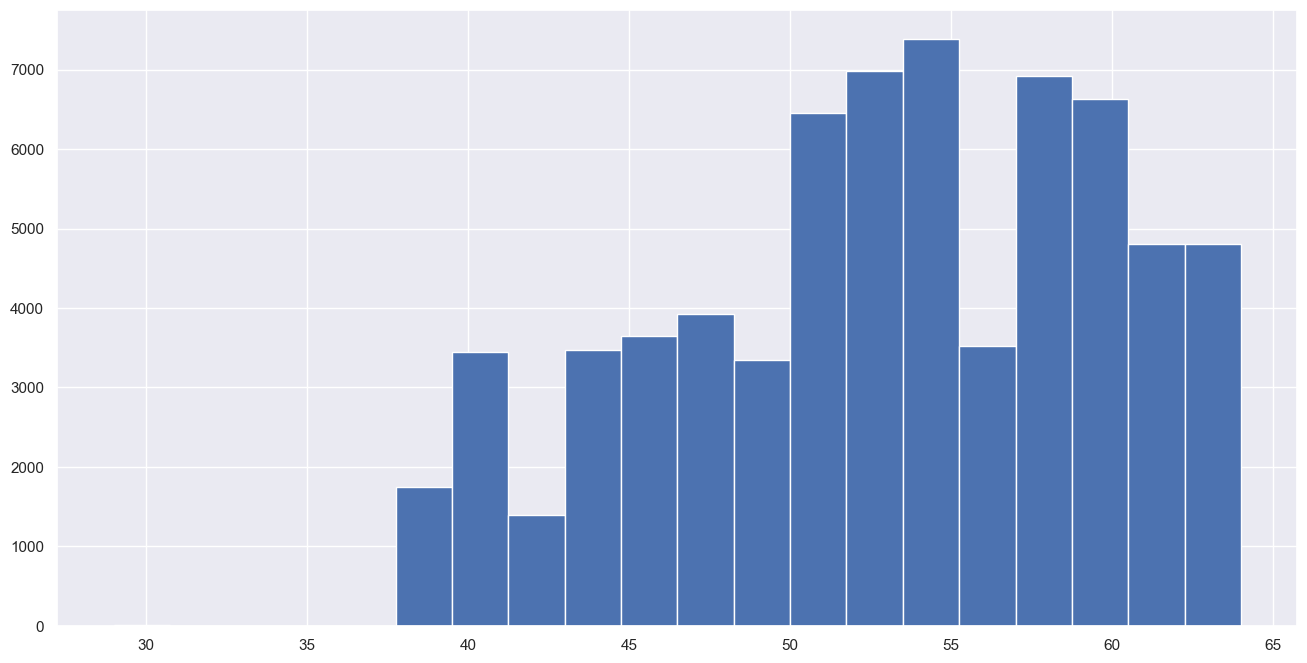

In [57]:
df4['age'].hist(bins = 20)